## Problema do caminho mínimo

In [3]:
%pip install pulp pandas networkx matplotlib -q

import pulp
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# DADOS
# Lista de arestas (não direcionadas) e pesos
arestas = [
    ('a', 'b', 7),
    ('a', 'd', 5),
    ('b', 'd', 9),
    ('b', 'c', 8),
    ('b', 'e', 7),
    ('c', 'e', 5),
    ('d', 'e', 15),
    ('d', 'f', 6),
    ('e', 'f', 8),
    ('e', 'g', 9),
    ('f', 'g', 11)
]

origem = 'a'
destino = 'g'

# Conjunto de nós
nos = set()
for u, v, w in arestas:
    nos.add(u)
    nos.add(v)
nos = sorted(nos)  # ['a','b','c','d','e','f','g']

# Criar matriz de pesos (para tabela)
n = len(nos)
indice = {no: i for i, no in enumerate(nos)}
peso_mat = [[0]*n for _ in range(n)]
for u, v, w in arestas:
    i, j = indice[u], indice[v]
    peso_mat[i][j] = w
    peso_mat[j][i] = w

df_pesos = pd.DataFrame(peso_mat, index=nos, columns=nos)
print("\n=== MATRIZ DE PESOS (arestas) ===\n")
display(df_pesos)

# MODELO PLI (CAMINHO MÍNIMO)
prob = pulp.LpProblem("Caminho_Minimo", pulp.LpMinimize)

# Criar variáveis binárias para cada aresta (direcionada)
# Para cada aresta não direcionada, criamos duas variáveis: x_ij e x_ji
x = {}
for u, v, w in arestas:
    x[(u, v)] = pulp.LpVariable(f"x_{u}_{v}", lowBound=0, upBound=1, cat='Binary')
    x[(v, u)] = pulp.LpVariable(f"x_{v}_{u}", lowBound=0, upBound=1, cat='Binary')

# Restrições de conservação de fluxo
for no in nos:
    fluxo_sai = pulp.lpSum(x[(no, viz)] for (u, viz) in x if u == no)
    fluxo_entra = pulp.lpSum(x[(viz, no)] for (viz, v) in x if v == no)
    if no == origem:
        prob += fluxo_sai - fluxo_entra == 1
    elif no == destino:
        prob += fluxo_sai - fluxo_entra == -1
    else:
        prob += fluxo_sai - fluxo_entra == 0

# Funcao obj: minimizar soma dos pesos * fluxo
prob += pulp.lpSum(w * x[(u, v)] for u, v, w in arestas) + \
        pulp.lpSum(w * x[(v, u)] for u, v, w in arestas)

prob.solve(pulp.PULP_CBC_CMD(msg=False))

# EXTRAIR CAMINHO
print("\n=== SOLUÇÃO ÓTIMA ===\n")
print(f"Status: {pulp.LpStatus[prob.status]}")
custo_total = pulp.value(prob.objective)
print(f"Custo total mínimo: {custo_total}\n")

# Reconstruir caminho partindo da origem
caminho = [origem]
atual = origem
while atual != destino:
    for (u, v) in x:
        if u == atual and x[(u, v)].varValue > 0.5:
            caminho.append(v)
            atual = v
            break
# Exibir caminho
print("Caminho encontrado:")
print(" -> ".join(caminho))

# Tabela de arestas usadas
arestas_usadas = []
custo_parcial = 0
for k in range(len(caminho)-1):
  u, v = caminho[k], caminho[k+1]
  # encontrar peso
  w = None
  for a, b, p in arestas:
    if (a == u and b == v) or (a == v and b == u):
      w = p
      break
  custo_parcial += w
  arestas_usadas.append({
    'Origem': u,
    'Destino': v,
    'Peso': w,
    'Custo Acumulado': custo_parcial
  })
df_arcos = pd.DataFrame(arestas_usadas)
print("\n=== ARCOS PERCORRIDOS ===\n")
display(df_arcos)

Note: you may need to restart the kernel to use updated packages.

=== MATRIZ DE PESOS (arestas) ===



,a,b,c,d,e,f,g
a,0,7,0,5,0,0,0
b,7,0,8,9,7,0,0
c,0,8,0,0,5,0,0
d,5,9,0,0,15,6,0
e,0,7,5,15,0,8,9
f,0,0,0,6,8,0,11
g,0,0,0,0,9,11,0



=== SOLUÇÃO ÓTIMA ===

Status: Optimal
Custo total mínimo: 22.0

Caminho encontrado:
a -> d -> f -> g

=== ARCOS PERCORRIDOS ===



,Origem,Destino,Peso,Custo Acumulado
0,a,d,5,5
1,d,f,6,11
2,f,g,11,22


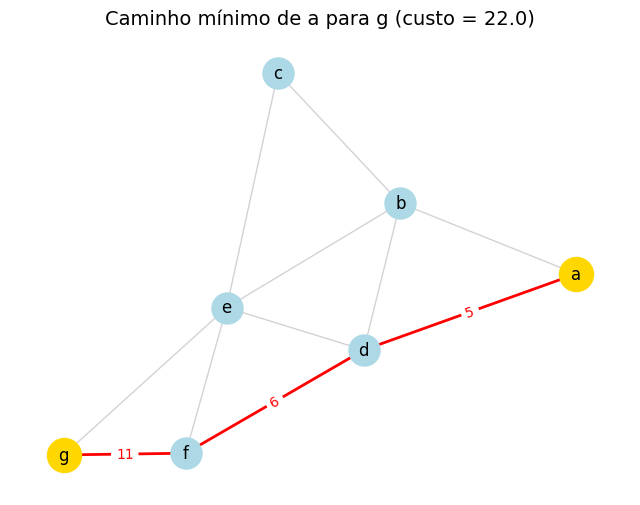

In [2]:
# Construir grafo
G = nx.Graph()
for u, v, w in arestas:
  G.add_edge(u, v, weight=w)

# Definir posições para desenho (layout fixo para visualização)
pos = nx.spring_layout(G, seed=42)  # ou use pos = nx.planar_layout(G)

plt.figure(figsize=(8,6))

# Desenhar todas as arestas (cinza)
nx.draw_networkx_edges(G, pos, edge_color='lightgray', width=1)

# Destacar arestas do caminho ótimo
caminho_arestas = [(caminho[k], caminho[k+1]) for k in range(len(caminho)-1)]
nx.draw_networkx_edges(G, pos, edgelist=caminho_arestas, edge_color='red', width=2)

# Desenhar nós
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_labels(G, pos, font_size=12)

# Destacar origem e destino
nx.draw_networkx_nodes(G, pos, nodelist=[origem], node_color='gold', node_size=600)
nx.draw_networkx_nodes(G, pos, nodelist=[destino], node_color='gold', node_size=600)

# Rótulos das distâncias nas arestas do caminho
edge_labels = {(caminho[k], caminho[k+1]): str(arestas_usadas[k]['Peso']) for k in range(len(caminho)-1)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=10)

plt.title(f"Caminho mínimo de {origem} para {destino} (custo = {custo_total})", fontsize=14)
plt.axis('off')
plt.show()